This notebook is designed to load neutron data and any non-neutron data (i.e. pressure, current, etc.) in an experimental folder, time bin it, and export it to CSV.

## Initialization

In [1]:
# TODO copy as "Ecell Fusion 2023-01-19" when more complete
# TODO remove dataset specific text when making finalized template

In [2]:
# Full notebook time profiling
from datetime import datetime
start_dt = datetime.now()

In [3]:
# Importing needed code

import re
from functools import reduce
from pathlib import Path
from typing import Callable, Literal, TypeVar
from datetime import datetime, time, date, timedelta
from dataclasses import dataclass

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statistics as stat

from data_processing.arc_paths import get_parq_root, get_report_root, get_exp_root
from data_processing.dataframe_validation import DataframeColumn
from data_processing.loading.dataframe_loading import load_psd
from data_processing.loading.timetag_processing import (
    calculate_timetag_hours, 
    calculate_event_time
)
from data_processing.processing.bimodal_fitting import (
    get_psd_energy_histogram, 
    scan_histogram_slices
)
from data_processing.processing.neutron_classification import (
    generate_nasa_neutron_window,
    classify
)
from data_processing.reporting.plotting import plot_classification,plot_tail_vs_total, plot_psd_histogram, plot_scatter
# from data_processing.processing.figure_of_merit import ( 
#     FOM, 
#     gaussian, 
#     bimodal
# )
from data_processing.helpers.stop_jupyter import stop

from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from mpl_toolkits.mplot3d import Axes3D

In [4]:
# Constants
SMOOTHING_WINDOW_SIZE = 5

In [5]:
T = TypeVar('T')
def get_input_with_default(prompt: str, default: int, converter: Callable[[str], T]) -> int:
    raw_value = input(prompt)
    try:
        value = converter(raw_value)
    except ValueError:
        value = default
    return value

In [6]:
def get_window_size(data_type: str) -> int:
    prompt = f"Enter smoothing window size for {data_type}, or press Enter for default (5):"
    return get_input_with_default(prompt, SMOOTHING_WINDOW_SIZE, int)

def load_non_neutron_data(exp_name, file_names):
    if not isinstance(file_names, list):
        file_names = [file_names]
    for file_name in file_names:
        file_path = get_exp_root(exp_name) / file_name
        if file_path.is_file():
            df = pd.read_csv(file_path)
            return df
    return None

def smooth_non_neutron_data(df, raw_data_col_name, smoothed_data_col_name, window_size):
    df[smoothed_data_col_name] = df[raw_data_col_name].rolling(
        window=window_size, min_periods=1).mean()
    return df

def localize_time(df, time_column):
    local_tz = 'America/Vancouver'
    naive_time = pd.to_datetime(df[time_column])
    try:
        localized_time = naive_time.dt.tz_localize(local_tz)
    except TypeError:
        localized_time = naive_time.dt.tz_convert(local_tz)
    df[time_column] = localized_time
    return df

In [7]:
def bin_non_neutron_data(df, time_bins, data_col, selected_cols):
    start_time = time_bins[0]
    df = get_time_cut(df, 'Time', time_bins)

    binned_df = df.groupby("Time Bin", as_index=False)[data_col].agg(['mean','std']).copy()
    binned_df.columns = selected_cols
    binned_df['Bin midpoint'] = binned_df.index.to_series().apply(lambda x: x.mid)
    binned_df = bin_midpoint_time_to_seconds(binned_df, start_time)
    
    return binned_df

In [8]:
def bin_midpoint_time_to_seconds(df, start_time):
    zeroed_midpoint = pd.to_datetime(df["Bin midpoint"]) - start_time
    df['Bin time (s)'] = zeroed_midpoint.dt.total_seconds()
    return df

In [9]:
def get_time_cut(df, time_tag_col, time_bins):
    timetag_cut = pd.cut(df[time_tag_col], bins=time_bins)
    df['Time Bin'] = timetag_cut
    return df

In [10]:
def get_endings_with_modifications(endings, string_method):
    modded_endings = [
        *endings,
        *[getattr(ending, string_method)() for ending in endings]
    ]
    return modded_endings

def get_possible_names(exp_name, endings):
    possible_names = [f"{exp_name}{ending}.csv" for ending in possible_filename_endings]
    return possible_names

def get_filenames_with_hyphenless_ids(exp_name, filenames):
    hyphenless = exp_name.replace('-', '')
    modded_filenames = [
        *filenames,
        *[filename.replace(exp_name, hyphenless) for filename in filenames]
    ]
    return modded_filenames

def get_full_possible_names_set(exp_name, endings):
    possible_names = get_possible_names(exp_name, endings)
    full_poss_names_set = get_filenames_with_hyphenless_ids(exp_name, possible_names)
    return full_poss_names_set

## Experiment ID Input

In [11]:
done = False
experiment_ids = []
while not done:
    experiment_ids = []
    while (id_input := input("Enter the ID number (just the number!), or Enter to finish: ")) != '':
        experiment_ids.append(id_input)
    experiment_ids = [f"ID-{exp_id}" for exp_id in experiment_ids]
    
    ids_valid = []
    for exp_id in experiment_ids:
        id_valid = get_parq_root(exp_id).is_dir()
        ids_valid.append(id_valid)
        if not id_valid:
            print(f"Experiment {exp_id} cannot be found")
    
    done = all(ids_valid)
    if not done:
        print("Invalid experiment IDs, please re-enter")
    else:
        print("All experiment IDs are valid")

Enter the ID number (just the number!), or Enter to finish:  338
Enter the ID number (just the number!), or Enter to finish:  


All experiment IDs are valid


In [12]:
removed_event_time = get_input_with_default(
    "Enter starting time (in seconds) to remove from EJ-309 detector data, or press Enter for default (0):", 
    0, 
    int)

Enter starting time (in seconds) to remove from EJ-309 detector data, or press Enter for default (0): 


In [13]:
pressure_window_size = get_window_size("pressure")

Enter smoothing window size for pressure, or press Enter for default (5): 


In [14]:
current_window_size = get_window_size("current")

Enter smoothing window size for current, or press Enter for default (5): 


In [15]:
mw_window_size = get_window_size("microwave power")

Enter smoothing window size for microwave power, or press Enter for default (5): 


In [16]:
bin_length = get_input_with_default(
    "Enter bin length (in seconds), or press Enter for default (60 s)",
    60,
    int
)
bin_string = f"{bin_length}S"

Enter bin length (in seconds), or press Enter for default (60 s) 120


## Data Loading and Initial Processing

### Neutron Data Processing

In [17]:
# Data Loading
experiment_neutron_data = {exp_id:load_psd(exp_id) for exp_id in experiment_ids}

In [18]:
# Remove starting events
def remove_time(psd_report):
    return psd_report[psd_report["TIMETAG"] >= removed_event_time * 1e12].copy()

experiment_neutron_data = {exp_id: remove_time(psd_report) for exp_id, psd_report in experiment_neutron_data.items()}

In [19]:
# Express timetags in hours elapsed
experiment_neutron_data = {exp_id:calculate_timetag_hours(psd_report) for exp_id, psd_report in experiment_neutron_data.items()}

In [20]:
# Classify neutrons
# experiment_neutron_data values are now dict containing multiple data values
# i.e. psd_report, classification bounds, etc.
start_scan_idx = 0
end_scan_idx = 420
L0 = 0.1966
window_offset = 0.2
sigma = 5

nan_total_threshold = 5
nan_window_threshold = 4
nan_rolling_window = 7
stop_here = False

for exp_name, psd_report in experiment_neutron_data.items():
    classification_data = {'unclassified': psd_report}
    
    Z, xe, ye = get_psd_energy_histogram(psd_report)

    end_scan_idx = min(end_scan_idx, len(Z))
    psd_bin_lbs = ye[:-1]    
    all_slice_xs = xe[:end_scan_idx]
    
    # Default
    default_bounds = (
        (0.1, 0.01, 1, 
         0.25, 0.01, 0),
        (0.2, 0.1, Z.max(),
         0.38, 0.04, 2000)
    )

    bounds_a = (
        (0.1, 0.01, 1, 
         0.35, 0.01, 0),
        (0.2, 0.1, Z.max(),
         0.36, 0.04, 2000)
    )

    bounds_b = (
        (0.1, 0.01, 1, 
         0.34, 0.01, 0),
        (0.2, 0.1, Z.max(),
         0.36, 0.03, 2000)
    )


    # Ranged Example
    bounds = [
        ((0,60), bounds_a),
    ]

    # df_fom = find_threshold_fom_slice(psd_bin_lbs, Z.T, bounds, 0, end_scan_idx)
    df, df_err = scan_histogram_slices(
        psd_bin_lbs, 
        Z.T,
        bounds=bounds,
        default_bounds=default_bounds, 
        start_idx = start_scan_idx, 
        end_idx = end_scan_idx
    )
    nan_rows = df.isna().any(axis=1)
    nan_rows = nan_rows[nan_rows]
    if nan_rows.shape[0] > 0:
        nan_indexes = np.where(nan_rows)[0]
        total_nan_rows = len(nan_indexes)
        rolling_nan_count = nan_rows.rolling(window=nan_rolling_window).sum().max()
        
        print(f"Fit issues in {exp_name}")
        print(f"Fit failed on following slice indexes: {nan_indexes}")
        
        if total_nan_rows > nan_total_threshold or rolling_nan_count > nan_window_threshold:
            print(f"Experiment {exp_name} could not be classified")
            print(f"Total failed slices: {total_nan_rows}")
            print(f"Max failed slices in a 7 slice window: {rolling_nan_count}")
            
            classification_data['psd_histogram'] = Z
            classification_data['histogram_x_edges'] = xe
            classification_data['histogram_y_edges'] = ye
            classification_data['valid_slice_fits'] = df.dropna().copy()
            classification_data['bad_slice_indexes'] = nan_indexes
            experiment_neutron_data[exp_name] = classification_data
            
            stop_here = True
            continue
        
        # remove nan row indexes from all_slice_xs
        all_slice_xs = np.delete(all_slice_xs, nan_indexes)
        # filter out all nan rows from df
        df = df.dropna().copy()
        # continue as normal to try fitting with bad rows ignored
    
    neutron_lb_fit, neutron_ub_fit = generate_nasa_neutron_window(df, 
                                                                  all_slice_xs, 
                                                                  window_offset=window_offset, 
                                                                  sigma=sigma)
    classification_data["neutron_lb_fit"] = neutron_lb_fit
    classification_data["neutron_ub_fit"] = neutron_ub_fit
    classified_df = classify(psd_report, neutron_lb_fit, neutron_ub_fit, DataframeColumn.NEUTRON_CLASS, le_cutoff=L0)
    
    classification_data["psd_report"] = classified_df
    experiment_neutron_data[exp_name] = classification_data

if stop_here:
    stop()

In [21]:
# Get experiment start time
for exp_name, data_dict in experiment_neutron_data.items():
    exp_root = get_exp_root(exp_name)
    with open(exp_root / 'exp_info.toml') as exp_info:
        exp_start_line = [line for line in exp_info if "exp_start" in line][0]
    exp_start_text = exp_start_line.replace("exp_start = ","").strip()
    exp_start = datetime.fromisoformat(exp_start_text)
    data_dict['start_time'] = exp_start

In [22]:
# Get timetag as clock time
for exp_name, data_dict in experiment_neutron_data.items():
    psd_report = data_dict["psd_report"]
    exp_start = data_dict['start_time']
    psd_report['TIMETAG_PS_REMAINDER'] = psd_report['TIMETAG'] % 1000
    timetag_ns_delta = pd.to_timedelta(psd_report["TIMETAG"]//1000)
    timetag_clock = timetag_ns_delta + exp_start
    psd_report["TIMETAG_CLOCK"]=timetag_clock

In [23]:
# Separate neutron and gamma events
for exp_name, data_dict in experiment_neutron_data.items():
    psd_report = data_dict["psd_report"]
    neutrons_only = psd_report.query("NASA").copy()
    gamma_only = psd_report.query("~NASA").copy()
    data_dict["neutrons_only"] = neutrons_only
    data_dict["gamma_only"] = gamma_only

### Non-Neutron Data Processing

In [24]:
possible_filename_endings = [
    " pressure",
    " p",
    "-p"
]
possible_filename_endings = get_endings_with_modifications(possible_filename_endings, 'title')

for exp_name, data_dict in experiment_neutron_data.items():
    possible_names = get_full_possible_names_set(exp_name, possible_filename_endings)
    dp = load_non_neutron_data(exp_name, possible_names)
    if dp is None:
        print(f"No pressure data file found for {exp_name}")
        continue
    dp = smooth_non_neutron_data(dp, 'EDWRG Pressure (Torr)', 'smoothed_pressure', pressure_window_size)
    dp = localize_time(dp, 'Time')
    data_dict['pressure_report'] = dp

No pressure data file found for ID-338


In [25]:
# TODO complete when I know more about how current is stored
possible_filename_endings = [
    " current",
    " i",
    "-i"
]
possible_filename_endings = get_endings_with_modifications(possible_filename_endings, 'title')

for exp_name, data_dict in experiment_neutron_data.items():
    possible_names = get_full_possible_names_set(exp_name, possible_filename_endings)
    di = load_non_neutron_data(exp_name, possible_names)
    if di is None:
        print(f"No current data file found for {exp_name}")
        continue
    di = smooth_non_neutron_data(di, 'Current(mA)', 'smoothed_current', current_window_size)
    di = localize_time(di, 'Time')
    data_dict['current_report'] = di

No current data file found for ID-338


In [26]:
short_endings = [
    " mw",
    "-mw"
]
short_endings = get_endings_with_modifications(short_endings, 'swapcase')
long_endings = [
    " microwave",
    "-microwave"
]
long_endings = get_endings_with_modifications(long_endings, 'title')
possible_filename_endings = [
    *short_endings,
    *long_endings
]

for exp_name, data_dict in experiment_neutron_data.items():
    # data_dict = load_non_neutron_data(data_dict, f'{exp_name} MW.csv', data_dict_key)
    # data_dict = smooth_non_neutron_data(data_dict, data_dict_key, 'Forward Microwave Power (W)', 'smoothed_fwd_power', mw_window_size)
    # experiment_neutron_data[exp_name] = data_dict
    possible_names = get_full_possible_names_set(exp_name, possible_filename_endings)
    dmw = load_non_neutron_data(exp_name, possible_names)
    if dmw is None:
        # report that it didn't find anything
        print(f"No microwave data file found for {exp_name}")
        continue
    dmw = smooth_non_neutron_data(dmw, 'Forward Microwave Power (W)', 'smoothed_fwd_power', mw_window_size)
    dmw = localize_time(dmw, 'Time')
    data_dict['microwave_report'] = dmw

No microwave data file found for ID-338


## Data Binning

In [27]:
# Create bins
for exp_name, data_dict in experiment_neutron_data.items():
    neutron_report = data_dict['neutrons_only']
    start_time = neutron_report["TIMETAG_CLOCK"].min()
    end_time = neutron_report["TIMETAG_CLOCK"].max()
    timetag_clock_bins = pd.date_range(start=start_time, end=end_time, freq=bin_string)
    data_dict['time_bins'] = timetag_clock_bins

In [28]:
# Bin neutron data
for exp_name, data_dict in experiment_neutron_data.items():
    neutron_report = data_dict['neutrons_only']
    time_bins = data_dict['time_bins']
    start_time = time_bins[0]
    
    binned_neutrons = get_time_cut(neutron_report, 'TIMETAG_CLOCK', time_bins)
    binned_neutrons = neutron_report.groupby("Time Bin", as_index=True).size().to_frame().copy()
    binned_neutrons.columns = ['count']
    binned_neutrons['count error'] = np.sqrt(binned_neutrons['count'])
    
    binned_neutron_time_bins = binned_neutrons.index.to_series()
    midpoints = binned_neutron_time_bins.apply(lambda x: x.mid)
    durations = binned_neutron_time_bins.apply(lambda x: x.length.total_seconds())
    
    binned_neutrons["Bin midpoint"] = midpoints
    binned_neutrons = bin_midpoint_time_to_seconds(binned_neutrons, start_time)
    
#     bin_duration = binned_neutrons.index.to_series().apply(lambda x: x.length.total_seconds())
    binned_neutrons['Neutron rate (cps)'] = binned_neutrons['count'] / durations
    binned_neutrons['Neutron error (cps)'] = binned_neutrons['count error'] / durations
    binned_neutrons = binned_neutrons.drop(['count', 'count error'], axis=1).copy()
    data_dict['binned_neutrons'] = binned_neutrons

In [29]:
# Bin gamma data
for exp_name, data_dict in experiment_neutron_data.items():
    gamma_report = data_dict['gamma_only']
    time_bins = data_dict['time_bins']
    start_time = time_bins[0]
    
    binned_gamma = get_time_cut(gamma_report, 'TIMETAG_CLOCK', time_bins)
    binned_gamma = gamma_report.groupby("Time Bin", as_index=True).size().to_frame().copy()
    binned_gamma.columns = ['count']
    binned_gamma['count error'] = np.sqrt(binned_gamma['count'])
    
    binned_gamma_time_bins = binned_gamma.index.to_series()
    midpoints = binned_gamma_time_bins.apply(lambda x: x.mid)
    durations = binned_gamma_time_bins.apply(lambda x: x.length.total_seconds())
    
    binned_gamma["Bin midpoint"] = midpoints
    binned_gamma = bin_midpoint_time_to_seconds(binned_gamma, start_time)
    
#     bin_duration = binned_neutrons.index.to_series().apply(lambda x: x.length.total_seconds())
    binned_gamma['Background gamma rate (cps)'] = binned_gamma['count'] / durations
    binned_gamma['Gamma error (cps)'] = binned_gamma['count error'] / durations
    binned_gamma = binned_gamma.drop(['count', 'count error'], axis=1).copy()
    data_dict['binned_gamma'] = binned_gamma

In [30]:
# Bin pressure data (if exists)
for exp_name, data_dict in experiment_neutron_data.items():
    if (pressure_report := data_dict.get('pressure_report')) is not None:
        time_bins = data_dict['time_bins']
        binned_pressure = bin_non_neutron_data(
            pressure_report, 
            time_bins, 
            'smoothed_pressure', 
            ['Average pressure (Torr)', 'Pressure error (Torr)']
        )
        
        data_dict['binned_pressure'] = binned_pressure

In [31]:
# Bin current data (if exists)
for exp_name, data_dict in experiment_neutron_data.items():
    if (current_report := data_dict.get('current_report')) is not None:
        time_bins = data_dict['time_bins']
        binned_current = bin_non_neutron_data(
            current_report,
            time_bins,
            'smoothed_current',
            ['Average current (mA)', 'Current error (mA)']
        )
        data_dict['binned_current'] = binned_current

In [32]:
# Bin microwave data (if exists)
for exp_name, data_dict in experiment_neutron_data.items():
    if (microwave_report := data_dict.get('microwave_report')) is not None:
        time_bins = data_dict['time_bins']
        binned_fwd_power = bin_non_neutron_data(
            microwave_report,
            time_bins,
            'smoothed_fwd_power',
            ['Average forward power (W)', 'Forward power error (W)']
        )
        data_dict['binned_fwd_power'] = binned_fwd_power

In [33]:
# Merge binned data
for exp_name, data_dict in experiment_neutron_data.items():
    binned_dfs = []
    binned_dfs.append(data_dict['binned_neutrons'])
    binned_dfs.append(data_dict['binned_gamma'])
    if (binned_pressure := data_dict.get('binned_pressure')) is not None:
        binned_dfs.append(binned_pressure)
    if (binned_current := data_dict.get('binned_current')) is not None:
        binned_dfs.append(binned_current)
    if (binned_fwd_power := data_dict.get('binned_fwd_power')) is not None:
        binned_dfs.append(binned_fwd_power)
    merged_df = reduce(lambda df1, df2: pd.merge(df1, df2, how='left', on=['Time Bin','Bin midpoint','Bin time (s)']), binned_dfs)
    data_dict['all_binned_data'] = merged_df

## Export and Display

In [34]:
# Export as CSV
for exp_name, data_dict in experiment_neutron_data.items():
    all_binned_data = data_dict['all_binned_data']
    output_path = get_report_root(exp_name) / f"{exp_name}_data_{bin_length}s_bin.csv"
    all_binned_data.to_csv(output_path, index=False)
    print(f"Experiment {exp_name} saved to {output_path}")

Experiment ID-338 saved to Q:\Neutron Data\3-Output\ID-338\ID-338_data_120s_bin.csv


In [35]:
# TODO Diagnostic plot

In [36]:
input("Processing done, hit Enter to finish")
stop()

Processing done, hit Enter to finish 


StopExecution: 

## Optional Diagnostics Display

In [37]:
done = False
valid_exp_ids = [x for x in experiment_neutron_data.keys()]
experiment_id = valid_exp_ids[0]
while not done:
    experiment_id = valid_exp_ids[0]
    if (id_input := input(f"Enter the ID number (just the number!), or Enter to get {experiment_id}: ")) != '':
        experiment_id = f"ID-{id_input}"
    
    done = experiment_id in valid_exp_ids
    if not done:
        print("Invalid experiment ID, please re-enter")
    else:
        print("Experiment ID is valid")

Enter the ID number (just the number!), or Enter to get ID-338:  338


Experiment ID is valid


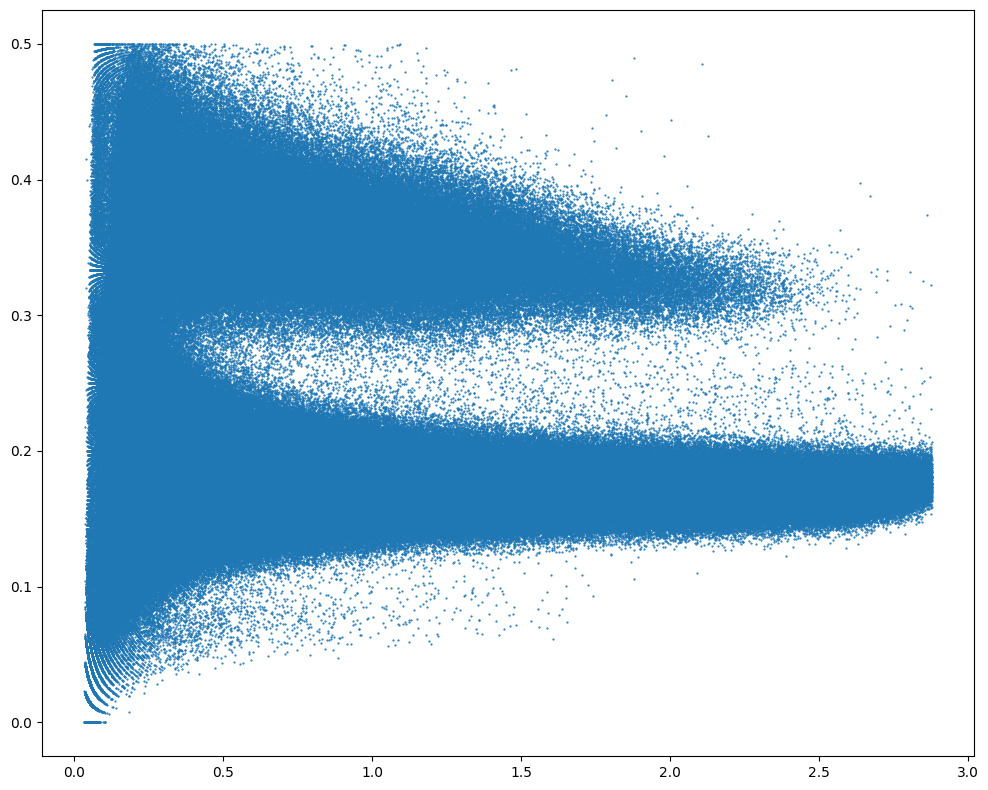

In [38]:
psd_report = experiment_neutron_data[experiment_id]['psd_report']
fig, ax = plot_scatter(psd_report["CALIB_ENERGY"], psd_report["tail / total"])
output_path = get_report_root(experiment_id) / f"{experiment_id} PSD graph.png"
fig.savefig(output_path)
plt.show()

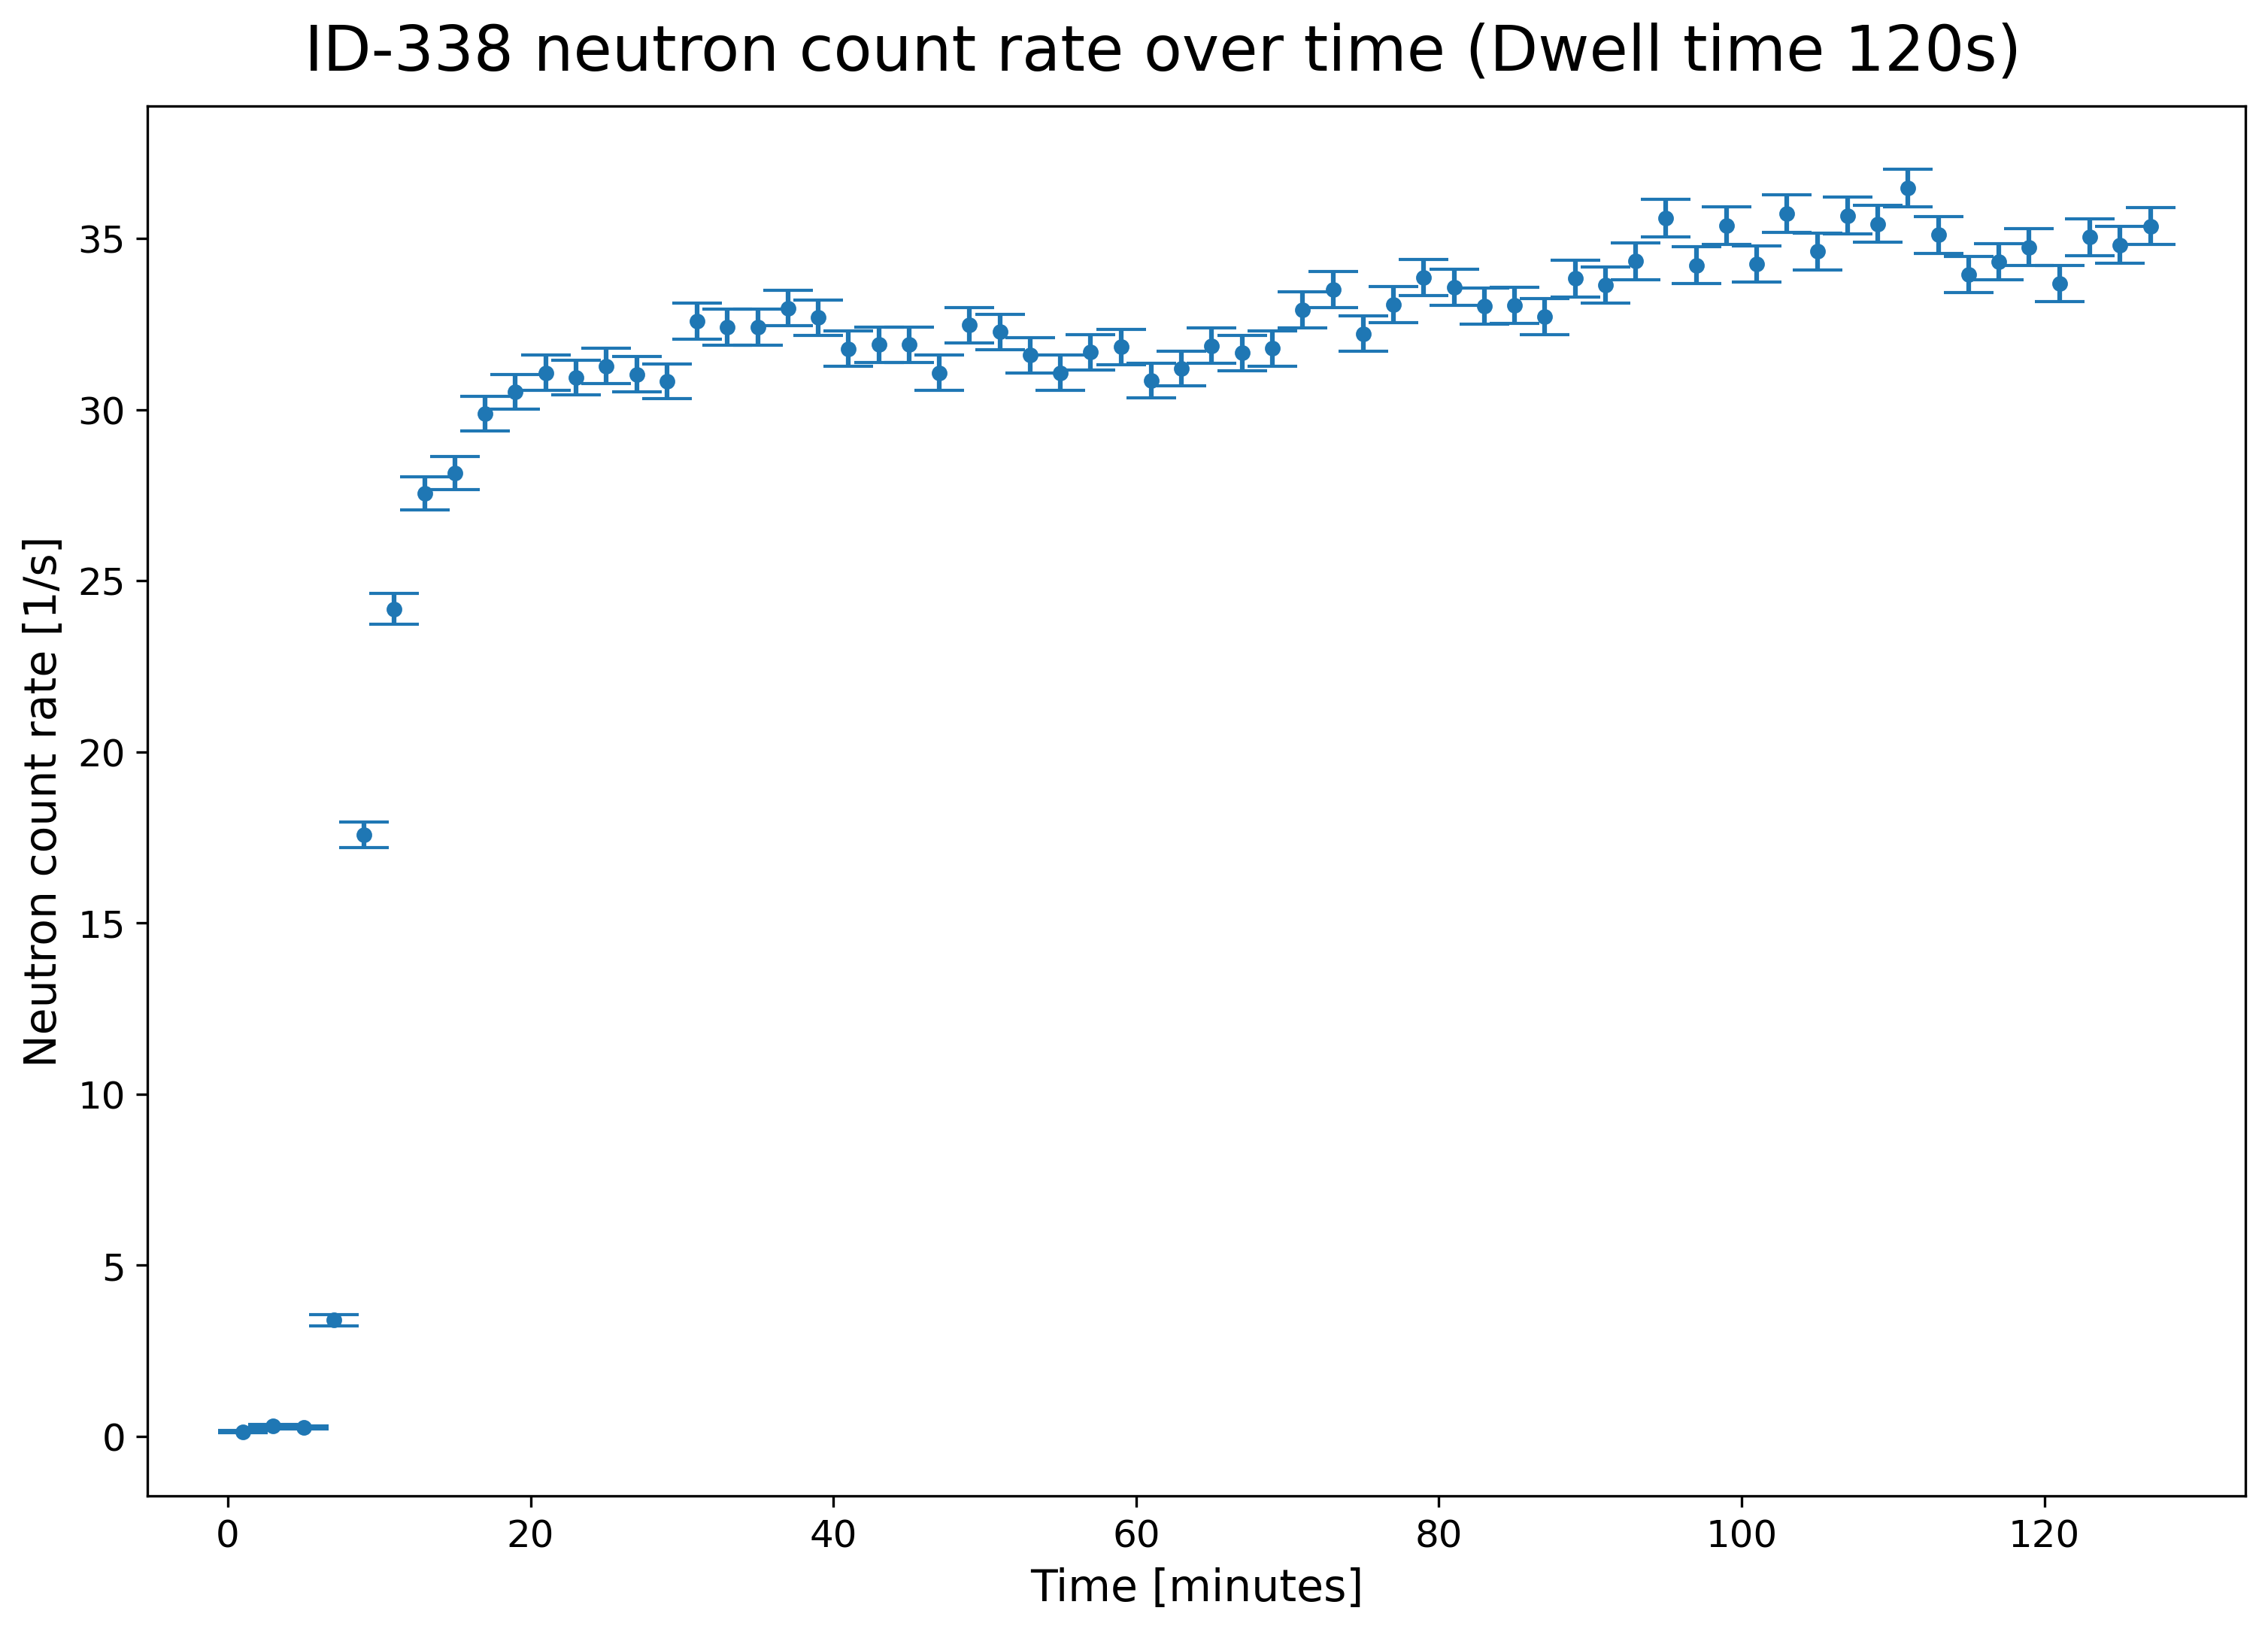

In [39]:
binned_neutrons = experiment_neutron_data[experiment_id]["all_binned_data"]
zeroed_bins = binned_neutrons['Bin time (s)'] / 60
rates = binned_neutrons['Neutron rate (cps)']
rate_errors = binned_neutrons['Neutron error (cps)']
fig, ax = plt.subplots(figsize=(12,8), dpi=300)
# fig, ax = plt.subplots()
dot_size = 8
ax.errorbar(zeroed_bins, rates, yerr=rate_errors, fmt=".", linestyle='', markersize=dot_size, capsize=dot_size)
ax.set_xlabel("Time [minutes]", fontsize=14)  # Update x-axis label
ax.set_ylabel("Neutron count rate [1/s]", fontsize=14)
# ax.tick_params(axis='y', labelcolor='orange')
ax.tick_params(labelsize=12)
# ax.set_ylim(0, 22)
# ax.set_ylim(3.5, 5.0)

# Add a title above the plot
fig.text(0.5, 0.90, f"{experiment_id} neutron count rate over time (Dwell time {bin_length}s)", ha='center', fontsize=20)

# Save the plot
output_path = get_report_root(experiment_id) / f"{experiment_id} Count rates {bin_length}s dwell.png"
fig.savefig(output_path)

# Show the plot (optional)
plt.show()